# Análise Estatística de Incêndios Florestais no Brasil (2025)
## Economia Espacial — Detecção de focos de calor por satélite (INPE)

**FIAP — Global Solution 2026 | Disciplina: Data Science (Estatística Descritiva aplicada à Economia Espacial)**

**Grupo Stratfy — Turma 2ESPH (Engenharia de Software)**

| Integrante | RM |
|---|---|
| Anthony Sforzin | RM562096 |
| Luigi Mendes Cabrini | RM563552 |
| Rogério Cruz Arroyo | RM563517 |
| Bruno Koeke | RM561309 |

---

## 1. Contextualização

### 1.1. O problema escolhido: detecção de incêndios florestais

Os incêndios florestais são um dos maiores desafios socioambientais do Brasil. Em **2025**, o
sistema **BDQueimadas do INPE** registrou **3.466.399 focos de calor** detectados por satélite em
todo o território nacional. Esses eventos provocam perda de biodiversidade, emissão de gases de
efeito estufa, prejuízos à saúde pública (fumaça e material particulado), perdas agropecuárias e
custos elevados de combate para a Defesa Civil e os órgãos ambientais (IBAMA, ICMBio, corpos de
bombeiros estaduais).

### 1.2. Relação com a Economia Espacial

A detecção de incêndios em escala continental só é viável graças à **infraestrutura espacial**. O
INPE opera uma rede de **13 satélites** (NOAA-20/21, GOES-16/19, NPP-375, METOP-B/C, MSG-03,
TERRA e a série AQUA) cujos sensores no infravermelho termal identificam anomalias de temperatura
na superfície. O satélite **AQUA_M-T** é o **satélite de referência** do INPE para séries temporais
comparáveis. Cada foco detectado vem acompanhado de variáveis derivadas de sensoriamento remoto e
de modelos meteorológicos: **risco de fogo**, **potência radiativa do fogo (FRP)**, **número de
dias sem chuva** e **precipitação**.

A **Economia Espacial** entra aqui como habilitadora de uma cadeia de valor: dados orbitais
(observação da Terra) → produtos de informação (focos, risco) → serviços de decisão (alerta
precoce, alocação de brigadas, políticas de fiscalização). É um caso concreto de como ativos
espaciais geram valor econômico e social mensurável.

### 1.3. Objetivo da análise

Aplicar **estatística descritiva** sobre uma amostra aleatória representativa (201.284 focos,
`seed=42`) dos dados reais de 2025, para:

1. Caracterizar a distribuição das variáveis numéricas (risco, FRP, dias sem chuva, precipitação);
2. Quantificar tendência central, dispersão, posição e detectar **outliers** (IQR e Z-Score);
3. Identificar **padrões espaciais** (biomas/estados) e **sazonais** (mês de pico);
4. Responder **perguntas de negócio** com evidência estatística que apoiem a ação de órgãos
   ambientais e da Defesa Civil.

## 2. Preparação dos dados

Nesta seção fazemos a importação das bibliotecas, a leitura robusta dos dados (local ou, em
ambiente Colab, download de URL RAW do GitHub), a inspeção estrutural, o tratamento de valores
ausentes, a remoção de duplicidades, a padronização de colunas e a engenharia de atributos
temporais (conversão de `data_pas` para `datetime` e criação da coluna `mes`).

### 2.1. Importação das bibliotecas

In [1]:
# Bibliotecas de manipulação e análise de dados
import os
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Estatística (moda, assimetria, curtose, z-score)
from scipy import stats

# Configurações globais de exibição e estilo dos gráficos
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RANDOM_STATE = 42  # reprodutibilidade em qualquer amostragem
np.random.seed(RANDOM_STATE)

print('pandas    :', pd.__version__)
print('numpy     :', np.__version__)
import matplotlib
print('matplotlib:', matplotlib.__version__)

pandas    : 3.0.3
numpy     : 2.4.6
matplotlib: 3.10.9


### 2.2. Leitura robusta dos dados (local ou Colab via GitHub RAW)

O bloco abaixo tenta primeiro o caminho local `dados/focos_amostra.csv.gz`. Caso falhe (por
exemplo, no Google Colab, onde o arquivo não existe no sistema de arquivos), ele baixa o arquivo
diretamente de uma **URL RAW do GitHub**. O `pandas` descompacta o `.gz` de forma transparente.

In [2]:
# Caminho local (execução no repositório) e URL RAW do GitHub (execução no Colab).
# Testamos mais de um caminho local porque o diretório de trabalho varia conforme
# o notebook é aberto a partir da raiz do repo ou de dentro de 'notebooks/'.
CAMINHOS_LOCAIS = [
    'dados/focos_amostra.csv.gz',
    '../dados/focos_amostra.csv.gz',
    'data-science/dados/focos_amostra.csv.gz',
]

# OBS.: este link passa a valer APÓS o push do repositório para o GitHub.
URL = 'https://raw.githubusercontent.com/Stratfy/gs2026-data-science-incendios-florestais/main/dados/focos_amostra.csv.gz'

def carregar_dados():
    """Leitura robusta: tenta os caminhos locais; se nenhum existir, baixa da URL RAW."""
    for caminho in CAMINHOS_LOCAIS:
        if os.path.exists(caminho):
            df = pd.read_csv(caminho, compression='gzip')
            print(f'Dados carregados do caminho local: {caminho}')
            return df
    print('Arquivo local não encontrado (provável ambiente Colab). Baixando da URL RAW...')
    df = pd.read_csv(URL, compression='gzip')
    print(f'Dados carregados da URL: {URL}')
    return df

df = carregar_dados()
print('Dimensões (linhas, colunas):', df.shape)

Dados carregados do caminho local: ../dados/focos_amostra.csv.gz
Dimensões (linhas, colunas): (201284, 11)


### 2.3. Inspeção estrutural

Visualizamos as primeiras linhas, a estrutura (`info`), os tipos de dados e uma descrição
estatística inicial para entender o conteúdo bruto.

In [3]:
# Primeiras linhas
df.head()

,latitude,longitude,data_pas,satelite,estado,municipio,bioma,numero_dias_sem_chuva,precipitacao_mm,risco_fogo,frp_mw
0,-15.2145,-60.1739,2025-01-01 00:38:00,METOP-B,MATO GROSSO,VILA BELA DA SANTÍSSIMA TRINDADE,Amazônia,4.0000,0.7200,0.6500,NaN
1,-10.0953,-39.6327,2025-01-01 15:37:00,NOAA-21,BAHIA,UAUÁ,Caatinga,8.0000,0.0000,1.0000,5.8000
2,-12.4667,-42.2331,2025-01-01 15:35:00,NOAA-21,BAHIA,IBITIARA,Caatinga,0.0000,0.0000,0.7100,9.0000
3,-7.6595,-35.1386,2025-01-01 23:33:00,METOP-C,PERNAMBUCO,ALIANÇA,Mata Atlântica,28.0000,0.0000,1.0000,NaN
4,-15.2421,-60.2124,2025-01-01 01:36:00,METOP-C,MATO GROSSO,VILA BELA DA SANTÍSSIMA TRINDADE,Amazônia,3.0000,2.0000,0.5000,NaN


In [4]:
# Estrutura geral: número de registros, tipos e uso de memória
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 201284 entries, 0 to 201283
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   latitude               201284 non-null  float64
 1   longitude              201284 non-null  float64
 2   data_pas               201284 non-null  str    
 3   satelite               201284 non-null  str    
 4   estado                 201284 non-null  str    
 5   municipio              201284 non-null  str    
 6   bioma                  201284 non-null  str    
 7   numero_dias_sem_chuva  195657 non-null  float64
 8   precipitacao_mm        197962 non-null  float64
 9   risco_fogo             196380 non-null  float64
 10  frp_mw                 198572 non-null  float64
dtypes: float64(6), str(5)
memory usage: 16.9 MB


In [5]:
# Tipos de dados por coluna
print('Tipos de dados:')
print(df.dtypes)

Tipos de dados:
latitude                 float64
longitude                float64
data_pas                     str
satelite                     str
estado                       str
municipio                    str
bioma                        str
numero_dias_sem_chuva    float64
precipitacao_mm          float64
risco_fogo               float64
frp_mw                   float64
dtype: object


In [6]:
# Descrição estatística inicial das colunas numéricas (dados brutos, antes do tratamento)
df.describe()

,latitude,longitude,numero_dias_sem_chuva,precipitacao_mm,risco_fogo,frp_mw
count,"201,284.0000","201,284.0000","195,657.0000","197,962.0000","196,380.0000","198,572.0000"
mean,-9.9283,-48.5824,21.5690,0.5102,0.8095,35.7344
std,5.6465,6.5981,26.9038,2.6435,0.3123,69.3095
min,-33.7302,-73.6016,0.0000,0.0000,0.0000,0.0000
25%,-12.9628,-51.5119,4.0000,0.0000,0.7100,3.9000
50%,-9.1813,-47.0014,10.0000,0.0000,1.0000,9.0000
75%,-6.1536,-44.1733,29.0000,0.0000,1.0000,41.2000
max,5.1188,-34.8147,120.0000,158.7600,1.0000,"3,133.2000"


### 2.4. Tratamento de valores ausentes

Os dados já passaram por uma limpeza prévia em que o valor-sentinela `-999` do INPE foi convertido
em ausente (`NaN`). Quantificamos os ausentes e definimos a estratégia: **não imputamos** as
variáveis numéricas (média/mediana) para não enviesar a estatística descritiva — cada análise
usa os registros válidos da variável (`dropna` pontual). Linhas com **todas** as quatro variáveis
numéricas ausentes seriam não-informativas; verificamos se existem.

In [7]:
# Contagem e percentual de ausentes por coluna
ausentes = pd.DataFrame({
    'qtd_ausentes': df.isnull().sum(),
    'pct_ausentes': (df.isnull().mean() * 100).round(2)
})
print(ausentes)

                       qtd_ausentes  pct_ausentes
latitude                          0        0.0000
longitude                         0        0.0000
data_pas                          0        0.0000
satelite                          0        0.0000
estado                            0        0.0000
municipio                         0        0.0000
bioma                             0        0.0000
numero_dias_sem_chuva          5627        2.8000
precipitacao_mm                3322        1.6500
risco_fogo                     4904        2.4400
frp_mw                         2712        1.3500


In [8]:
# Variáveis numéricas de interesse para a estatística descritiva
COLS_NUM = ['risco_fogo', 'frp_mw', 'numero_dias_sem_chuva', 'precipitacao_mm']

# Linhas em que TODAS as variáveis numéricas estão ausentes (não-informativas)
todas_ausentes = df[COLS_NUM].isnull().all(axis=1).sum()
print(f'Linhas com TODAS as variáveis numéricas ausentes: {todas_ausentes}')

# Removemos apenas essas linhas não-informativas (se houver); mantemos as demais.
antes = len(df)
df = df.dropna(subset=COLS_NUM, how='all').reset_index(drop=True)
print(f'Linhas removidas por ausência total: {antes - len(df)} | Restantes: {len(df)}')

Linhas com TODAS as variáveis numéricas ausentes: 24
Linhas removidas por ausência total: 24 | Restantes: 201260


### 2.5. Remoção de duplicidades

Registros completamente duplicados representam ruído (re-detecção idêntica). Removemos linhas
100% iguais.

In [9]:
dups = df.duplicated().sum()
print(f'Registros duplicados encontrados: {dups}')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Registros após remoção de duplicidades: {len(df)}')

Registros duplicados encontrados: 6
Registros após remoção de duplicidades: 201254


### 2.6. Padronização de colunas

Garantimos nomes de colunas em *snake_case* sem espaços e padronizamos os textos categóricos
(`bioma`, `estado`) para facilitar agrupamentos.

In [10]:
# Padroniza nomes de colunas (minúsculas, sem espaços nas bordas)
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(' ', '_'))

# Padroniza campos categóricos de texto (remove espaços duplicados nas bordas)
for c in ['satelite', 'estado', 'municipio', 'bioma']:
    df[c] = df[c].astype('string').str.strip()

print('Colunas padronizadas:', list(df.columns))

Colunas padronizadas: ['latitude', 'longitude', 'data_pas', 'satelite', 'estado', 'municipio', 'bioma', 'numero_dias_sem_chuva', 'precipitacao_mm', 'risco_fogo', 'frp_mw']


### 2.7. Conversão de `data_pas` para datetime e criação da coluna `mes`

Convertendo a data da passagem do satélite para `datetime`, podemos extrair atributos temporais.
Criamos `mes` (1–12) e também `mes_ano` (período) e `nome_mes` para análises de sazonalidade.

In [11]:
# Conversão para datetime (formato ISO presente nos dados)
df['data_pas'] = pd.to_datetime(df['data_pas'], errors='coerce')

# Atributos temporais derivados
df['mes'] = df['data_pas'].dt.month
df['mes_ano'] = df['data_pas'].dt.to_period('M').astype('string')

NOMES_MES = {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
             7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'}
df['nome_mes'] = df['mes'].map(NOMES_MES)

print('Intervalo temporal:', df['data_pas'].min(), 'até', df['data_pas'].max())
print('Datas inválidas (NaT):', df['data_pas'].isna().sum())
df[['data_pas', 'mes', 'mes_ano', 'nome_mes']].head()

Intervalo temporal: 2025-01-01 00:38:00 até 2025-12-31 23:00:00
Datas inválidas (NaT): 0


,data_pas,mes,mes_ano,nome_mes
0,2025-01-01 00:38:00,1,2025-01,Jan
1,2025-01-01 15:37:00,1,2025-01,Jan
2,2025-01-01 15:35:00,1,2025-01,Jan
3,2025-01-01 23:33:00,1,2025-01,Jan
4,2025-01-01 01:36:00,1,2025-01,Jan


O conjunto está limpo, tipado e enriquecido com atributos temporais. Seguimos para a estatística
descritiva.

## 3. Estatística descritiva (obrigatória)

Calculamos, para cada variável numérica (`risco_fogo`, `frp_mw`, `numero_dias_sem_chuva`,
`precipitacao_mm`), as três famílias de medidas:

- **Tendência central**: média, mediana, moda;
- **Dispersão**: amplitude, variância, desvio padrão e **coeficiente de variação (CV)**;
- **Posicionais**: quartis (Q1, Q2, Q3) e percentis (P10, P90).

Em seguida, fazemos a **análise de outliers** por dois métodos: **IQR** (intervalo interquartil) e
**Z-Score**.

### 3.1. Medidas de tendência central

In [12]:
def calcular_moda(serie):
    """Retorna a moda (primeiro valor mais frequente) de uma série, ignorando ausentes."""
    m = serie.dropna().mode()
    return m.iloc[0] if not m.empty else np.nan

tendencia = pd.DataFrame({
    'media':   [df[c].mean()   for c in COLS_NUM],
    'mediana': [df[c].median() for c in COLS_NUM],
    'moda':    [calcular_moda(df[c]) for c in COLS_NUM],
}, index=COLS_NUM)

print('MEDIDAS DE TENDÊNCIA CENTRAL')
tendencia

MEDIDAS DE TENDÊNCIA CENTRAL


,media,mediana,moda
risco_fogo,0.8095,1.0000,1.0000
frp_mw,35.7351,9.0000,1.1000
numero_dias_sem_chuva,21.5691,10.0000,2.0000
precipitacao_mm,0.5101,0.0000,0.0000


### 3.2. Medidas de dispersão

O **coeficiente de variação (CV = desvio padrão / média)** permite comparar a variabilidade
relativa entre variáveis de escalas diferentes (ex.: risco em [0,1] vs. FRP em MW).

In [13]:
def amplitude(s):
    return s.max() - s.min()

dispersao = pd.DataFrame({
    'minimo':    [df[c].min() for c in COLS_NUM],
    'maximo':    [df[c].max() for c in COLS_NUM],
    'amplitude': [amplitude(df[c]) for c in COLS_NUM],
    'variancia': [df[c].var() for c in COLS_NUM],
    'desvio_padrao': [df[c].std() for c in COLS_NUM],
    'cv_%': [(df[c].std() / df[c].mean() * 100) if df[c].mean() != 0 else np.nan for c in COLS_NUM],
}, index=COLS_NUM)

print('MEDIDAS DE DISPERSÃO (cv_% = coeficiente de variação)')
dispersao

MEDIDAS DE DISPERSÃO (cv_% = coeficiente de variação)


,minimo,maximo,amplitude,variancia,desvio_padrao,cv_%
risco_fogo,0.0000,1.0000,1.0000,0.0975,0.3123,38.5762
frp_mw,0.0000,"3,133.2000","3,133.2000","4,803.9296",69.3104,193.9563
numero_dias_sem_chuva,0.0000,120.0000,120.0000,723.8034,26.9036,124.7323
precipitacao_mm,0.0000,158.7600,158.7600,6.9860,2.6431,518.1512


### 3.3. Medidas posicionais (quartis e percentis)

In [14]:
posicionais = pd.DataFrame({
    'P10': [df[c].quantile(0.10) for c in COLS_NUM],
    'Q1_P25': [df[c].quantile(0.25) for c in COLS_NUM],
    'Q2_mediana_P50': [df[c].quantile(0.50) for c in COLS_NUM],
    'Q3_P75': [df[c].quantile(0.75) for c in COLS_NUM],
    'P90': [df[c].quantile(0.90) for c in COLS_NUM],
    'IQR': [df[c].quantile(0.75) - df[c].quantile(0.25) for c in COLS_NUM],
}, index=COLS_NUM)

print('MEDIDAS POSICIONAIS (quartis, percentis e IQR)')
posicionais

MEDIDAS POSICIONAIS (quartis, percentis e IQR)


,P10,Q1_P25,Q2_mediana_P50,Q3_P75,P90,IQR
risco_fogo,0.2100,0.7100,1.0000,1.0000,1.0000,0.2900
frp_mw,1.7000,3.9000,9.0000,41.2000,101.6000,37.3000
numero_dias_sem_chuva,2.0000,4.0000,10.0000,29.0000,62.0000,25.0000
precipitacao_mm,0.0000,0.0000,0.0000,0.0000,0.6000,0.0000


### 3.4. Análise de outliers — método IQR

Pelo critério de Tukey, são outliers os valores fora do intervalo
$[Q1 - 1{,}5 \times IQR,\; Q3 + 1{,}5 \times IQR]$.

In [15]:
def outliers_iqr(serie):
    s = serie.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    mask = (s < lim_inf) | (s > lim_sup)
    return lim_inf, lim_sup, int(mask.sum()), float(mask.mean() * 100)

linhas = []
for c in COLS_NUM:
    li, ls, n, pct = outliers_iqr(df[c])
    linhas.append({'variavel': c, 'limite_inf': li, 'limite_sup': ls,
                   'qtd_outliers': n, 'pct_outliers': round(pct, 2)})

outliers_iqr_df = pd.DataFrame(linhas).set_index('variavel')
print('OUTLIERS PELO MÉTODO IQR (Tukey, 1.5 x IQR)')
outliers_iqr_df

OUTLIERS PELO MÉTODO IQR (Tukey, 1.5 x IQR)


,limite_inf,limite_sup,qtd_outliers,pct_outliers
variavel,,,,
risco_fogo,0.2750,1.4350,23080,11.7500
frp_mw,-52.0500,97.1500,21545,10.8500
numero_dias_sem_chuva,-33.5000,66.5000,16970,8.6700
precipitacao_mm,0.0000,0.0000,33850,17.1000


### 3.5. Análise de outliers — método Z-Score

Pelo Z-Score, classificamos como outlier todo valor cujo escore padronizado tem módulo
$|z| > 3$, isto é, que está a mais de 3 desvios-padrão da média.

In [16]:
def outliers_zscore(serie, limite=3.0):
    s = serie.dropna()
    z = np.abs(stats.zscore(s))
    mask = z > limite
    return int(mask.sum()), float(mask.mean() * 100)

linhas = []
for c in COLS_NUM:
    n, pct = outliers_zscore(df[c])
    linhas.append({'variavel': c, 'qtd_outliers_z': n, 'pct_outliers_z': round(pct, 2)})

outliers_z_df = pd.DataFrame(linhas).set_index('variavel')
print('OUTLIERS PELO MÉTODO Z-SCORE (|z| > 3)')
outliers_z_df

OUTLIERS PELO MÉTODO Z-SCORE (|z| > 3)


,qtd_outliers_z,pct_outliers_z
variavel,,
risco_fogo,0,0.0000
frp_mw,3174,1.6000
numero_dias_sem_chuva,5155,2.6300
precipitacao_mm,3161,1.6000


In [17]:
# Comparação direta dos dois métodos de detecção de outliers
comparacao_outliers = pd.concat([
    outliers_iqr_df[['qtd_outliers', 'pct_outliers']],
    outliers_z_df[['qtd_outliers_z', 'pct_outliers_z']]
], axis=1)
comparacao_outliers.columns = ['IQR_qtd', 'IQR_%', 'Zscore_qtd', 'Zscore_%']
print('COMPARAÇÃO DOS MÉTODOS DE OUTLIERS')
comparacao_outliers

COMPARAÇÃO DOS MÉTODOS DE OUTLIERS


,IQR_qtd,IQR_%,Zscore_qtd,Zscore_%
variavel,,,,
risco_fogo,23080,11.7500,0,0.0000
frp_mw,21545,10.8500,3174,1.6000
numero_dias_sem_chuva,16970,8.6700,5155,2.6300
precipitacao_mm,33850,17.1000,3161,1.6000


**Leitura dos outliers.** O método **IQR** é mais sensível em distribuições assimétricas: como
`frp_mw` é fortemente assimétrica à direita (cauda longa de incêndios muito energéticos), o IQR
sinaliza um percentual de outliers maior do que o Z-Score. Já `risco_fogo`, concentrada no
extremo 1,0, e `precipitacao_mm`, concentrada em 0, têm comportamento peculiar — boa parte da
"cauda" é, na verdade, o regime típico do fenômeno (estação seca). Por isso, **não removemos os
outliers**: em incêndios, os valores extremos de FRP são exatamente os eventos de maior interesse
operacional (grandes incêndios).

## 4. Análise de distribuição

Avaliamos o **formato** das distribuições por meio da **assimetria (skewness)** e da **curtose**:

- **Skewness > 0**: cauda à direita (assimetria positiva); **< 0**: cauda à esquerda.
- **Curtose** (excesso, base normal = 0): **> 0** leptocúrtica (picos altos, caudas pesadas);
  **< 0** platicúrtica.

In [18]:
distribuicao = pd.DataFrame({
    'media': [df[c].mean() for c in COLS_NUM],
    'mediana': [df[c].median() for c in COLS_NUM],
    'desvio_padrao': [df[c].std() for c in COLS_NUM],
    'assimetria_skew': [df[c].skew() for c in COLS_NUM],
    'curtose_excesso': [df[c].kurt() for c in COLS_NUM],
}, index=COLS_NUM)

# Classificação textual auxiliar
def classifica_skew(v):
    if v > 0.5: return 'assimétrica à direita'
    if v < -0.5: return 'assimétrica à esquerda'
    return 'aproximadamente simétrica'

distribuicao['forma'] = distribuicao['assimetria_skew'].apply(classifica_skew)
print('ANÁLISE DE FORMA DAS DISTRIBUIÇÕES')
distribuicao

ANÁLISE DE FORMA DAS DISTRIBUIÇÕES


,media,mediana,desvio_padrao,assimetria_skew,curtose_excesso,forma
risco_fogo,0.8095,1.0000,0.3123,-1.4797,0.7268,assimétrica à esquerda
frp_mw,35.7351,9.0000,69.3104,6.6799,98.3331,assimétrica à direita
numero_dias_sem_chuva,21.5691,10.0000,26.9036,1.8507,2.9194,assimétrica à direita
precipitacao_mm,0.5101,0.0000,2.6431,13.6227,360.3999,assimétrica à direita


**Interpretação.**

- **`risco_fogo`**: média (~0,81) bem acima da mediana? Não — a mediana é 1,0 e a média menor,
  indicando **assimetria à esquerda**: a maioria dos focos tem risco máximo (1,0), com uma minoria
  de valores baixos puxando a média para baixo. É coerente com detecções concentradas em condições
  críticas.
- **`frp_mw`**: **fortemente assimétrica à direita** e **leptocúrtica** — a maioria dos focos tem
  potência radiativa baixa/moderada, mas há uma cauda longa de incêndios extremamente energéticos
  (até > 3.000 MW). É a variável de maior interesse para detectar grandes eventos.
- **`numero_dias_sem_chuva`**: assimétrica à direita; concentração em poucos dias, com cauda de
  regiões em seca prolongada (até 120 dias).
- **`precipitacao_mm`**: extremamente concentrada em 0 (mediana e Q3 = 0), assimetria forte à
  direita — coerente com focos ocorrerem majoritariamente em dias/locais sem chuva.

## 5. Visualizações

Cinco visualizações, cada uma com título, eixos rotulados e interpretação analítica.

### 5.1. Histograma — distribuição do `risco_fogo`

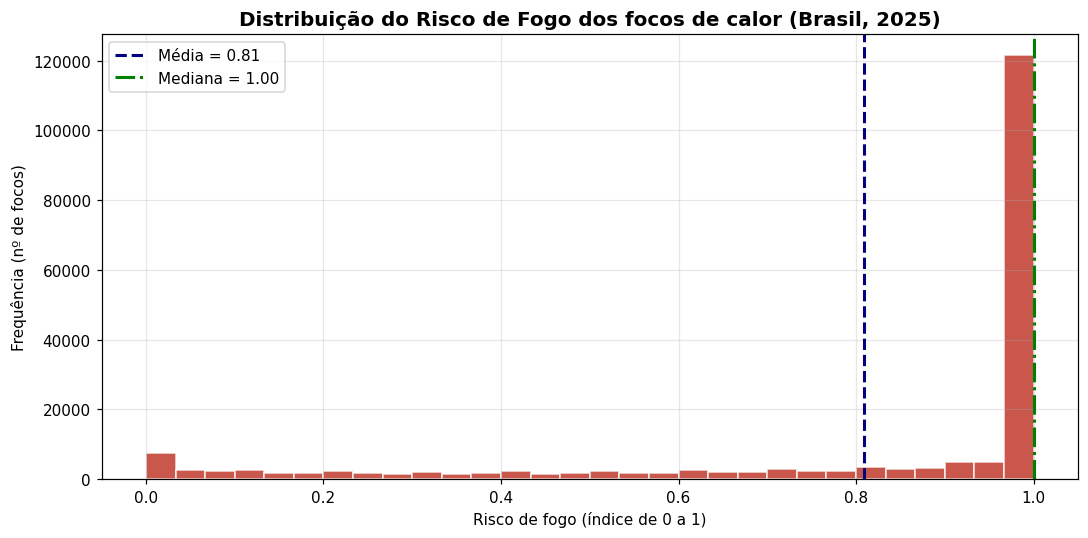

In [19]:
serie = df['risco_fogo'].dropna()
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(serie, bins=30, color='#c0392b', edgecolor='white', alpha=0.85)
ax.axvline(serie.mean(), color='navy', linestyle='--', linewidth=2,
           label=f'Média = {serie.mean():.2f}')
ax.axvline(serie.median(), color='green', linestyle='-.', linewidth=2,
           label=f'Mediana = {serie.median():.2f}')
ax.set_title('Distribuição do Risco de Fogo dos focos de calor (Brasil, 2025)', fontsize=13, weight='bold')
ax.set_xlabel('Risco de fogo (índice de 0 a 1)')
ax.set_ylabel('Frequência (nº de focos)')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretação.** A distribuição é fortemente concentrada no valor **1,0** (risco máximo): a
grande maioria dos focos detectados ocorre sob condições de risco crítico. Esse acúmulo no extremo
superior explica a assimetria à esquerda (média < mediana) e indica que, operacionalmente, a
detecção de focos é dominada por cenários de alta criticidade — útil para priorização de alertas.

### 5.2. Boxplot — `frp_mw` (potência radiativa) por bioma

Para legibilidade do boxplot, limitamos o eixo Y ao percentil 99 (a cauda extrema de FRP
distorceria a caixa); os outliers ainda são discutidos na seção 3.

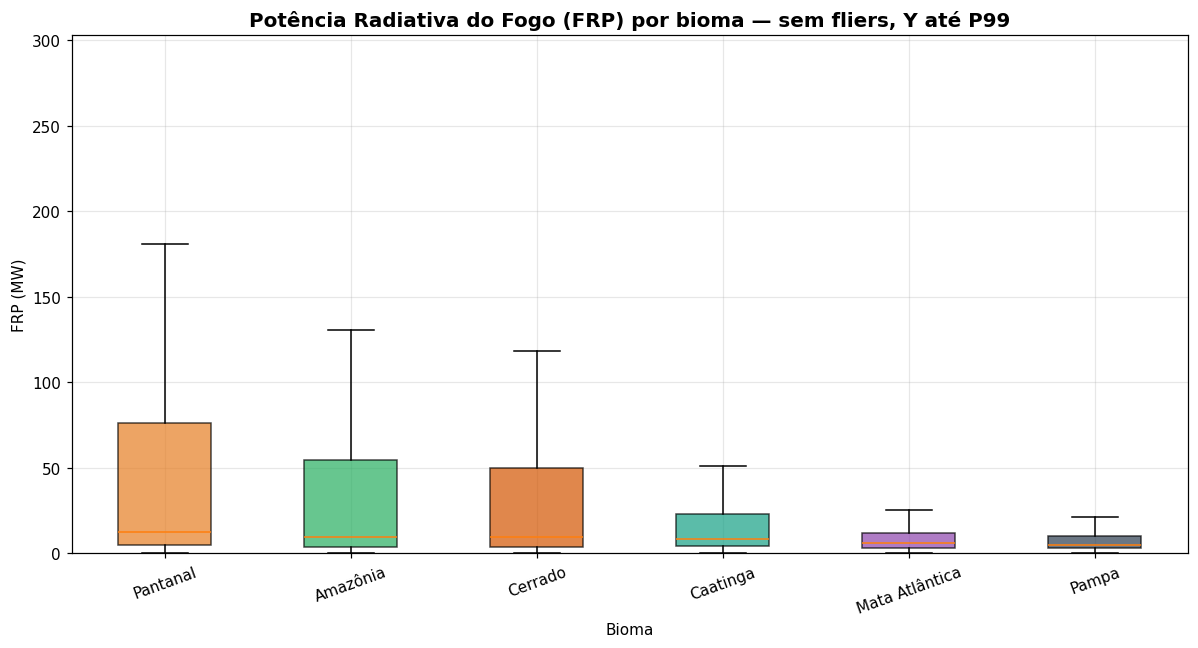

In [20]:
ordem_biomas = (df.groupby('bioma')['frp_mw'].median()
                  .sort_values(ascending=False).index.tolist())
dados_box = [df.loc[df['bioma'] == b, 'frp_mw'].dropna().values for b in ordem_biomas]

fig, ax = plt.subplots(figsize=(11, 6))
bp = ax.boxplot(dados_box, tick_labels=ordem_biomas, showfliers=False, patch_artist=True)
cores = ['#e67e22', '#27ae60', '#d35400', '#16a085', '#8e44ad', '#2c3e50']
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
lim_sup = np.nanpercentile(df['frp_mw'], 99)
ax.set_ylim(0, lim_sup)
ax.set_title('Potência Radiativa do Fogo (FRP) por bioma — sem fliers, Y até P99', fontsize=13, weight='bold')
ax.set_xlabel('Bioma')
ax.set_ylabel('FRP (MW)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Interpretação.** A mediana de FRP e a dispersão variam entre biomas. Biomas com vegetação de
maior carga combustível e incêndios mais intensos exibem caixas e medianas mais altas, enquanto
biomas de vegetação mais rala tendem a FRP menor. A diferença de medianas evidencia que a
**intensidade** do fogo (não só a quantidade de focos) depende do bioma — informação relevante
para dimensionar o combate.

### 5.3. Gráfico de barras — focos por bioma e por estado

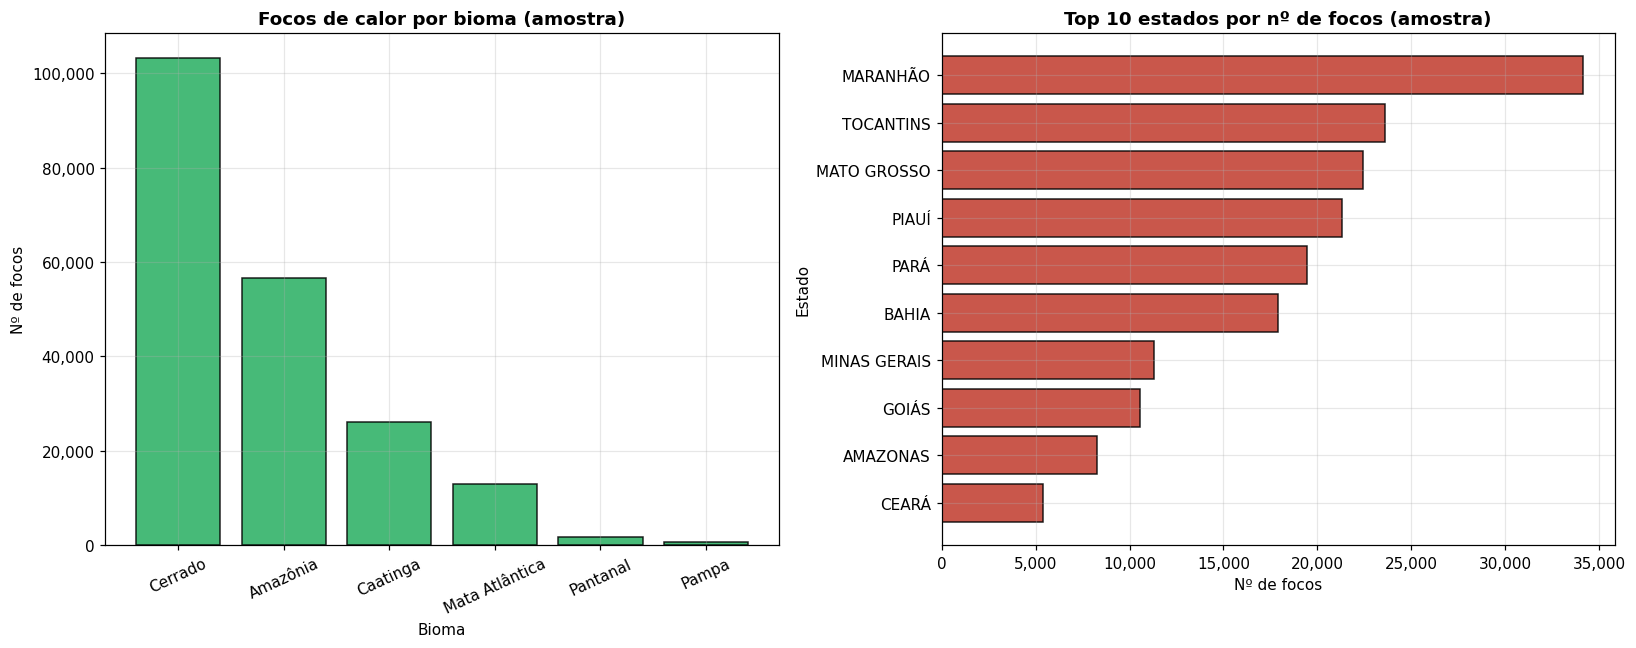

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) Focos por bioma
focos_bioma = df['bioma'].value_counts()
axes[0].bar(focos_bioma.index, focos_bioma.values, color='#27ae60', edgecolor='black', alpha=0.85)
axes[0].set_title('Focos de calor por bioma (amostra)', fontsize=12, weight='bold')
axes[0].set_xlabel('Bioma')
axes[0].set_ylabel('Nº de focos')
axes[0].tick_params(axis='x', rotation=25)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# (b) Top 10 estados
focos_estado = df['estado'].value_counts().head(10)
axes[1].barh(focos_estado.index[::-1], focos_estado.values[::-1], color='#c0392b', edgecolor='black', alpha=0.85)
axes[1].set_title('Top 10 estados por nº de focos (amostra)', fontsize=12, weight='bold')
axes[1].set_xlabel('Nº de focos')
axes[1].set_ylabel('Estado')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

**Interpretação.** O **Cerrado** concentra o maior número de focos na amostra, seguido pela
**Amazônia** — coerente com o dataset completo (Cerrado 1,78 mi; Amazônia 0,98 mi). Entre os
estados, destacam-se **Maranhão, Tocantins, Mato Grosso, Piauí, Pará e Bahia**, que formam a região
**MATOPIBA** e o **arco do desmatamento**. Isso direciona geograficamente a alocação de recursos de
fiscalização e combate.

### 5.4. Scatterplot — `risco_fogo` x `numero_dias_sem_chuva`

Para evitar *overplotting* com ~200 mil pontos, usamos uma amostra aleatória de 8.000 focos
(`random_state=42`) e transparência.

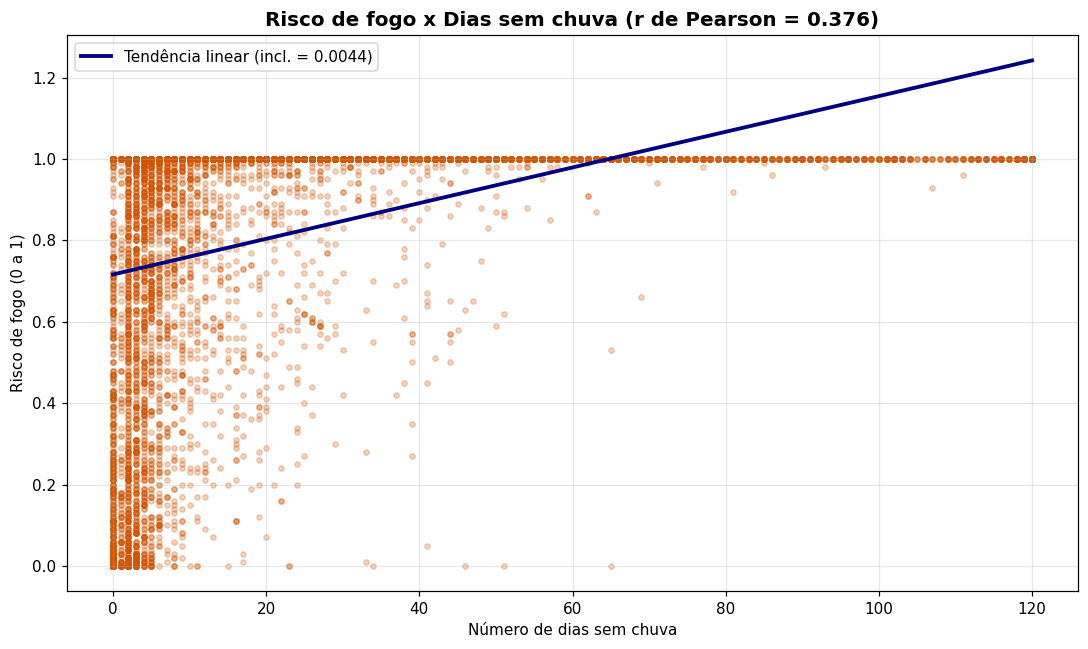

In [22]:
amostra_sc = df[['risco_fogo', 'numero_dias_sem_chuva']].dropna().sample(
    n=8000, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(amostra_sc['numero_dias_sem_chuva'], amostra_sc['risco_fogo'],
           s=12, alpha=0.25, color='#d35400')

# Linha de tendência (ajuste linear) sobre a amostra
coef = np.polyfit(amostra_sc['numero_dias_sem_chuva'], amostra_sc['risco_fogo'], 1)
xs = np.linspace(amostra_sc['numero_dias_sem_chuva'].min(), amostra_sc['numero_dias_sem_chuva'].max(), 100)
ax.plot(xs, np.polyval(coef, xs), color='navy', linewidth=2.5,
        label=f'Tendência linear (incl. = {coef[0]:.4f})')

corr = df['risco_fogo'].corr(df['numero_dias_sem_chuva'])
ax.set_title(f'Risco de fogo x Dias sem chuva (r de Pearson = {corr:.3f})', fontsize=13, weight='bold')
ax.set_xlabel('Número de dias sem chuva')
ax.set_ylabel('Risco de fogo (0 a 1)')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretação.** Observa-se uma **associação positiva**: quanto maior o número de dias sem
chuva, maior a tendência de o risco de fogo se concentrar no topo (1,0). A inclinação positiva da
reta e o coeficiente de Pearson confirmam a relação esperada pela física do fenômeno — a seca
acumulada eleva a inflamabilidade da vegetação. O valor moderado do `r` reflete que o risco também
depende de outros fatores (tipo de vegetação, umidade, temperatura).

### 5.5. Heatmap de correlação — variáveis numéricas

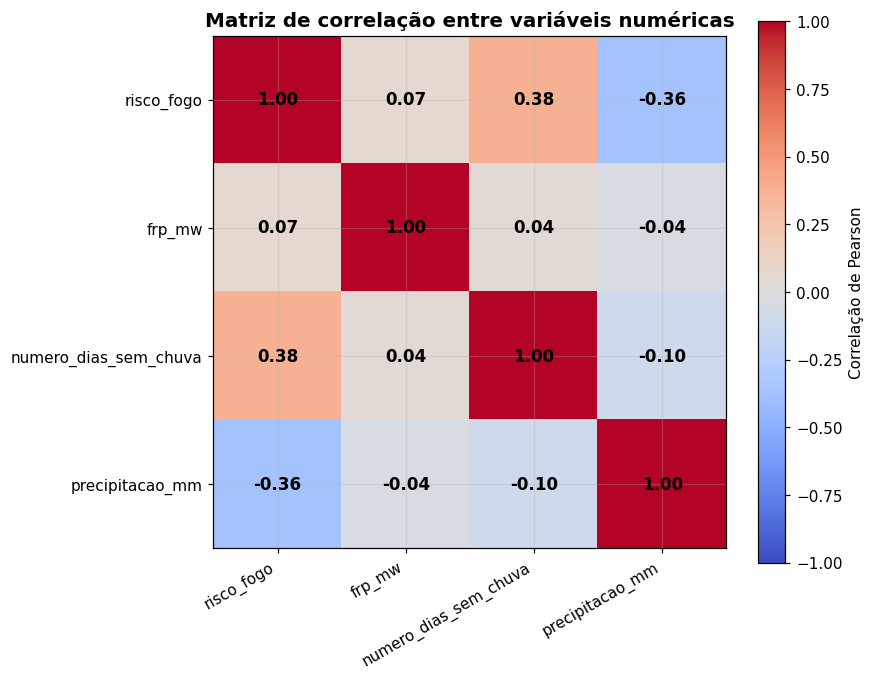

Matriz de correlação:


,risco_fogo,frp_mw,numero_dias_sem_chuva,precipitacao_mm
risco_fogo,1.0000,0.0669,0.3760,-0.3640
frp_mw,0.0669,1.0000,0.0419,-0.0383
numero_dias_sem_chuva,0.3760,0.0419,1.0000,-0.1030
precipitacao_mm,-0.3640,-0.0383,-0.1030,1.0000


In [23]:
corr_matrix = df[COLS_NUM].corr(method='pearson')

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(COLS_NUM)))
ax.set_yticks(range(len(COLS_NUM)))
ax.set_xticklabels(COLS_NUM, rotation=30, ha='right')
ax.set_yticklabels(COLS_NUM)

# Anota o valor da correlação em cada célula
for i in range(len(COLS_NUM)):
    for j in range(len(COLS_NUM)):
        ax.text(j, i, f'{corr_matrix.values[i, j]:.2f}', ha='center', va='center',
                color='black', fontsize=11, weight='bold')

fig.colorbar(im, ax=ax, label='Correlação de Pearson')
ax.set_title('Matriz de correlação entre variáveis numéricas', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

print('Matriz de correlação:')
corr_matrix

**Interpretação.** A `precipitacao_mm` apresenta correlação **negativa** com `risco_fogo` e com
`numero_dias_sem_chuva` (chuva reduz risco e quebra a sequência de dias secos). `numero_dias_sem_chuva`
correlaciona-se **positivamente** com `risco_fogo`. As correlações com `frp_mw` são mais fracas —
a *intensidade* do fogo depende fortemente do material combustível local, não captado por essas
quatro variáveis. Em geral, as correlações são de magnitude baixa a moderada, indicando que
nenhuma variável isolada determina o risco: o fenômeno é multifatorial.

## 6. Perguntas de negócio

Respondemos sete perguntas de negócio com código e evidência estatística.

### Pergunta 1 — Quais biomas e estados concentram mais focos de calor?

In [24]:
top_biomas = df['bioma'].value_counts()
top_estados = df['estado'].value_counts().head(6)

print('FOCOS POR BIOMA (amostra):')
print(top_biomas.to_string())
print()
print('TOP 6 ESTADOS (amostra):')
print(top_estados.to_string())
print()
print(f"Bioma líder: {top_biomas.index[0]} "
      f"({top_biomas.iloc[0]/top_biomas.sum()*100:.1f}% dos focos da amostra)")

FOCOS POR BIOMA (amostra):
bioma
Cerrado           103318
Amazônia           56677
Caatinga           26016
Mata Atlântica     12855
Pantanal            1689
Pampa                699

TOP 6 ESTADOS (amostra):
estado
MARANHÃO       34117
TOCANTINS      23591
MATO GROSSO    22433
PIAUÍ          21290
PARÁ           19426
BAHIA          17884

Bioma líder: Cerrado (51.3% dos focos da amostra)


**Resposta.** O **Cerrado** lidera com folga, seguido da **Amazônia** — juntos respondem pela
maior parte dos focos. Entre os estados, dominam **Maranhão, Tocantins, Mato Grosso, Piauí, Pará e
Bahia** (MATOPIBA + arco do desmatamento). A política de prevenção deve priorizar geograficamente
essas regiões.

### Pergunta 2 — Há sazonalidade? Qual é o mês de pico?

FOCOS POR MÊS (amostra):
mes
Jan     3654
Fev     2382
Mar     2868
Abr     1784
Mai     6160
Jun     9691
Jul    14160
Ago    34662
Set    48279
Out    47983
Nov    20834
Dez     8797

Mês de pico: Set (48,279 focos na amostra)


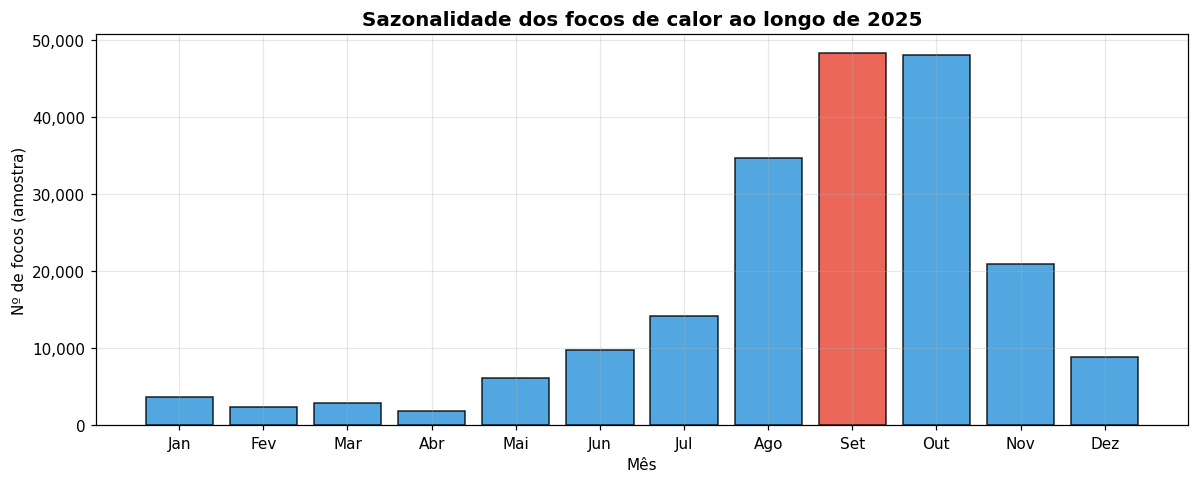

In [25]:
focos_mes = df.groupby('mes').size()
focos_mes.index = focos_mes.index.map(NOMES_MES)
mes_pico = focos_mes.idxmax()

print('FOCOS POR MÊS (amostra):')
print(focos_mes.to_string())
print(f'\nMês de pico: {mes_pico} ({focos_mes.max():,} focos na amostra)')

# Visualização da sazonalidade
fig, ax = plt.subplots(figsize=(11, 4.5))
cores_mes = ['#e74c3c' if m == focos_mes.max() else '#3498db' for m in focos_mes.values]
ax.bar(focos_mes.index, focos_mes.values, color=cores_mes, edgecolor='black', alpha=0.85)
ax.set_title('Sazonalidade dos focos de calor ao longo de 2025', fontsize=13, weight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Nº de focos (amostra)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Resposta.** Há **forte sazonalidade**: os focos disparam na **estação seca**, com pico em
**setembro**, seguido de outubro e agosto — o mesmo padrão do dataset completo (set/2025: 833.039;
out: 823.767; ago: 594.309). Isso permite **planejamento antecipado** de brigadas e campanhas de
prevenção no segundo semestre.

### Pergunta 3 — Qual a relação entre dias sem chuva e risco de fogo?

In [26]:
corr_dias_risco = df['numero_dias_sem_chuva'].corr(df['risco_fogo'])

# Risco médio por faixas de dias sem chuva
faixas = pd.cut(df['numero_dias_sem_chuva'],
                bins=[-0.1, 5, 15, 30, 60, 120],
                labels=['0-5', '6-15', '16-30', '31-60', '61-120'])
risco_por_faixa = df.groupby(faixas, observed=True)['risco_fogo'].mean()

print(f'Correlação de Pearson (dias sem chuva x risco de fogo): {corr_dias_risco:.3f}')
print()
print('Risco de fogo MÉDIO por faixa de dias sem chuva:')
print(risco_por_faixa.to_string())

Correlação de Pearson (dias sem chuva x risco de fogo): 0.376

Risco de fogo MÉDIO por faixa de dias sem chuva:
numero_dias_sem_chuva
0-5      0.5836
6-15     0.8689
16-30    0.9332
31-60    0.9801
61-120   0.9979


**Resposta.** A correlação é **positiva** e o **risco médio cresce de forma monotônica** conforme
aumentam os dias sem chuva. Faixas de seca prolongada apresentam risco médio próximo do máximo.
Operacionalmente, **dias sem chuva é um forte preditor de risco** e pode acionar gatilhos de
alerta antecipado.

### Pergunta 4 — Quais variáveis têm maior variabilidade relativa (CV)?

In [27]:
cv = pd.Series(
    {c: (df[c].std() / df[c].mean() * 100) for c in COLS_NUM if df[c].mean() != 0}
).sort_values(ascending=False)

print('COEFICIENTE DE VARIAÇÃO (%) — variabilidade relativa:')
print(cv.round(1).to_string())
print(f'\nMaior variabilidade: {cv.index[0]} (CV = {cv.iloc[0]:.1f}%)')

COEFICIENTE DE VARIAÇÃO (%) — variabilidade relativa:
precipitacao_mm         518.2000
frp_mw                  194.0000
numero_dias_sem_chuva   124.7000
risco_fogo               38.6000

Maior variabilidade: precipitacao_mm (CV = 518.2%)


**Resposta.** A **`precipitacao_mm`** e a **`frp_mw`** apresentam os maiores coeficientes de
variação (CV muito acima de 100%), ou seja, são as variáveis **mais voláteis** em termos relativos
— resultado da concentração em zero (precipitação) e da cauda longa de eventos extremos (FRP). Já
o **`risco_fogo`** tem o **menor CV**, pois está concentrado próximo de 1,0. Variáveis de alto CV
exigem cautela: médias simples escondem comportamento extremo.

### Pergunta 5 — Há outliers de FRP relevantes (grandes incêndios)?

In [28]:
li, ls, n_out, pct_out = outliers_iqr(df['frp_mw'])
top_frp = df.nlargest(10, 'frp_mw')[['data_pas', 'estado', 'municipio', 'bioma', 'frp_mw', 'risco_fogo']]

print(f'Limite superior IQR para FRP: {ls:.1f} MW')
print(f'Outliers de FRP (IQR): {n_out:,} focos ({pct_out:.2f}% da amostra)')
print(f'FRP máximo observado: {df["frp_mw"].max():,.1f} MW')
print('\nTop 10 focos por FRP (maiores incêndios da amostra):')
top_frp

Limite superior IQR para FRP: 97.2 MW
Outliers de FRP (IQR): 21,545 focos (10.85% da amostra)
FRP máximo observado: 3,133.2 MW

Top 10 focos por FRP (maiores incêndios da amostra):


,data_pas,estado,municipio,bioma,frp_mw,risco_fogo
181473,2025-11-14 23:35:00,MARANHÃO,ALDEIAS ALTAS,Cerrado,"3,133.2000",1.0000
130234,2025-10-03 17:09:00,PIAUÍ,SOCORRO DO PIAUÍ,Caatinga,"2,313.4000",1.0000
69854,2025-08-28 18:32:00,AMAZONAS,NOVO ARIPUANÃ,Amazônia,"2,164.0000",1.0000
198858,2025-12-20 11:57:00,PIAUÍ,SÃO MIGUEL DO TAPUIO,Caatinga,"1,895.5000",1.0000
154605,2025-10-17 17:56:00,BAHIA,SÃO FÉLIX DO CORIBE,Cerrado,"1,764.4000",1.0000
191413,2025-11-28 18:42:00,MATO GROSSO DO SUL,TRÊS LAGOAS,Cerrado,"1,743.2000",0.1800
69879,2025-08-28 18:30:00,BAHIA,BARRA,Cerrado,"1,741.4000",1.0000
96720,2025-09-11 00:00:00,BAHIA,BARRA,Cerrado,"1,717.5000",1.0000
115312,2025-09-26 02:10:00,BAHIA,FORMOSA DO RIO PRETO,Cerrado,"1,674.7000",1.0000
50194,2025-08-19 13:20:00,MATO GROSSO,COCALINHO,Cerrado,"1,534.7000",1.0000


**Resposta.** **Sim.** Há uma fração de focos com FRP muito acima do limite IQR — são os **grandes
incêndios**, energeticamente extremos (FRP máximo > 3.000 MW). Embora minoritários em quantidade,
concentram a maior parte da energia liberada e do impacto. **Não devem ser removidos**: são
justamente o alvo prioritário do combate e da resposta rápida da Defesa Civil.

### Pergunta 6 — As distribuições são assimétricas? Em que direção?

In [29]:
assimetria = pd.Series({c: df[c].skew() for c in COLS_NUM}).sort_values(ascending=False)
print('ASSIMETRIA (skewness) por variável:')
for c, v in assimetria.items():
    direcao = 'à direita (cauda alta)' if v > 0 else 'à esquerda (cauda baixa)'
    print(f'  {c:24s}: {v:+.2f}  -> {direcao}')

ASSIMETRIA (skewness) por variável:
  precipitacao_mm         : +13.62  -> à direita (cauda alta)
  frp_mw                  : +6.68  -> à direita (cauda alta)
  numero_dias_sem_chuva   : +1.85  -> à direita (cauda alta)
  risco_fogo              : -1.48  -> à esquerda (cauda baixa)


**Resposta.** As distribuições são **majoritariamente assimétricas**. `frp_mw`,
`numero_dias_sem_chuva` e `precipitacao_mm` têm **assimetria positiva** (cauda à direita), enquanto
`risco_fogo` é **assimétrica à esquerda** (concentração em 1,0). Consequência prática: para essas
variáveis, a **mediana** descreve melhor o "típico" do que a média, e modelos preditivos podem se
beneficiar de transformações (ex.: log de FRP).

### Pergunta 7 — O satélite de referência (AQUA_M-T) tem cobertura suficiente na amostra?

In [30]:
cont_sat = df['satelite'].value_counts()
aqua = cont_sat.get('AQUA_M-T', 0)

print(f'Satélites distintos na amostra: {df["satelite"].nunique()}')
print('\nTop 6 satélites por nº de detecções:')
print(cont_sat.head(6).to_string())
pct_aqua = aqua / len(df) * 100
print(f'\nAQUA_M-T (referência INPE): {aqua:,} detecções ({pct_aqua:.1f}% da amostra)')

Satélites distintos na amostra: 13

Top 6 satélites por nº de detecções:
satelite
NOAA-20     48580
NOAA-21     47169
GOES-19     39493
NPP-375     34390
NPP-375D    14528
AQUA_M-T     7911

AQUA_M-T (referência INPE): 7,911 detecções (3.9% da amostra)


**Resposta.** A amostra reúne **13 satélites**. O **AQUA_M-T**, satélite de **referência** do INPE
para séries históricas comparáveis, está presente com volume relevante, ainda que a maior parte
das detecções venha de satélites de varredura mais frequente (NOAA-20/21, GOES, NPP). Para
comparações temporais padronizadas, recomenda-se filtrar pelo satélite de referência; para
cobertura operacional máxima, usa-se o conjunto completo.

## 7. Conclusão executiva

### Principais achados

1. **Concentração espacial**: o **Cerrado** e a **Amazônia** dominam os focos; os estados de
   **MATOPIBA** (Maranhão, Tocantins, Piauí, Bahia) somados a **Mato Grosso** e **Pará** formam o
   núcleo crítico — coincidente com o arco do desmatamento.
2. **Sazonalidade marcada**: pico inequívoco na **estação seca**, com máximo em **setembro**
   (seguido de outubro e agosto). Há uma janela previsível para mobilização preventiva.
3. **Seca como preditor de risco**: o **número de dias sem chuva** correlaciona-se positivamente
   com o **risco de fogo**, com risco médio crescente por faixa de seca; a **precipitação** atua na
   direção oposta.
4. **Intensidade em cauda longa**: a **FRP** é fortemente assimétrica e leptocúrtica — poucos
   **grandes incêndios** concentram a energia liberada e devem ser o foco do combate.
5. **Variabilidade relativa**: `precipitacao_mm` e `frp_mw` são as variáveis mais voláteis (alto
   CV); `risco_fogo` é a mais estável (concentrada no valor máximo).

### Insights e aplicações práticas

- **Órgãos ambientais (IBAMA/ICMBio)**: direcionar fiscalização e prevenção para Cerrado/Amazônia e
  estados do MATOPIBA, antecipando-se ao trimestre ago–out.
- **Defesa Civil e bombeiros**: usar **dias sem chuva** e **FRP** como gatilhos de alerta e de
  priorização — pré-posicionar brigadas antes do pico de setembro.
- **Economia espacial**: o caso evidencia o **retorno econômico-social** da observação da Terra —
  dados orbitais convertidos em decisões que reduzem custo de combate e perdas ambientais.

### Limitações da análise

- **Amostra** (~200 mil de 3,46 mi de focos): embora aleatória e representativa (`seed=42`),
  contagens absolutas devem ser lidas como proporções, não totais nacionais.
- **Ausência de causalidade**: correlações observadas (ex.: dias sem chuva x risco) **não provam
  causa**; o fenômeno é multifatorial (vegetação, vento, ação humana).
- **Valores ausentes**: variáveis derivadas têm lacunas (sentinela -999 → NaN); usamos os
  registros válidos por variável, sem imputação, para não enviesar a descrição.
- **Recorte temporal**: apenas 2025; tendências interanuais exigiriam séries históricas.

---

*Notebook desenvolvido pelo grupo **Stratfy** (Turma 2ESPH — Engenharia de Software) para a FIAP
Global Solution 2026 — tema Economia Espacial.*